In [1]:
%pip install seaborn lightgbm scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)

   ---------------------------------------- 0/6 [joblib]
   ---------------------------------------- 0/6 [joblib]
   ---------------------------------------- 0/6 [joblib]
   -----------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

print(train.shape, test.shape, sub.shape)
train.head()

(699635, 23) (299844, 22) (299844, 2)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


In [3]:
TARGET = 'satisfaction'

info = pd.DataFrame({
    'dtype': train.dtypes,
    'n_unique': train.nunique(),
    'null_train': train.isnull().sum(),
    'null_test': test.reindex(columns=train.columns).isnull().sum(),
})
info['null_rate_train(%)'] = (info['null_train'] / len(train) * 100).round(2)
info

,dtype,n_unique,null_train,null_test,null_rate_train(%)
id,int64,699635,0,0,0.00
Age,int64,75,0,0,0.00
Flight Distance,int64,3474,0,0,0.00
Inflight wifi service,int64,6,0,0,0.00
Departure/Arrival time convenient,int64,6,0,0,0.00
Ease of Online booking,int64,6,0,0,0.00
Gate location,int64,6,0,0,0.00
Food and drink,int64,6,0,0,0.00
Online boarding,int64,6,0,0,0.00
Seat comfort,int64,6,0,0,0.00


In [4]:
print(train['satisfaction'].value_counts(normalize=True))

satisfaction
False    0.556427
True     0.443573
Name: proportion, dtype: float64


In [5]:
CAT_COLS = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

y01 = train['satisfaction'].astype(int)
for c in CAT_COLS:
    print(y01.groupby(train[c]).agg(['mean', 'count']), '\n')

            mean   count
Gender                  
Female  0.437994  347952
Male    0.449092  351683 

                       mean   count
Customer Type                      
Loyal Customer     0.495145  576990
disloyal Customer  0.200946  122645 

                     mean   count
Type of Travel                   
Business travel  0.584337  497441
Personal Travel  0.097263  202194 

              mean   count
Class                     
Business  0.725311  342212
Eco       0.167558  327404
Eco Plus  0.242180   30019 



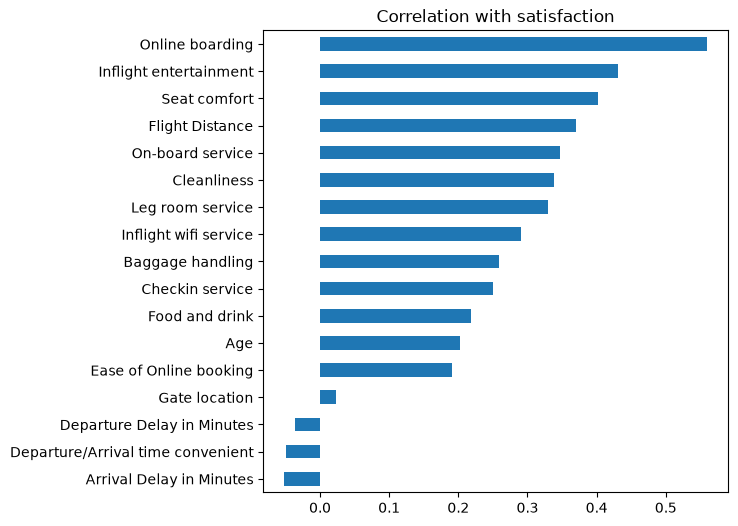

In [6]:
num_cols = [c for c in train.columns if c not in ['id', 'satisfaction'] + CAT_COLS]
corr = train[num_cols].corrwith(y01).sort_values()
corr.plot.barh(figsize=(6, 6)); plt.title('Correlation with satisfaction'); plt.show()

In [7]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

TARGET = 'satisfaction'
CAT_COLS = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# ① 目的変数：True/False → 1/0
y = train[TARGET].astype(int)

# ② 特徴量：idと目的変数以外すべて。カテゴリ列はcategory型に変換
feats = [c for c in train.columns if c not in ['id', TARGET]]
X, X_test = train[feats].copy(), test[feats].copy()
for c in CAT_COLS:
    cats = pd.api.types.CategoricalDtype(pd.concat([X[c], X_test[c]]).unique())
    X[c], X_test[c] = X[c].astype(cats), X_test[c].astype(cats)

# ③ 5-fold CV
oof = np.zeros(len(X))
pred = np.zeros(len(X_test))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr, va) in enumerate(skf.split(X, y)):
    model = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.05, num_leaves=63,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.7, verbose=-1)
    model.fit(X.iloc[tr], y.iloc[tr],
              eval_set=[(X.iloc[va], y.iloc[va])], eval_metric='auc',
              callbacks=[lgb.early_stopping(200, verbose=False)])

    oof[va] = model.predict_proba(X.iloc[va])[:, 1]
    pred += model.predict_proba(X_test)[:, 1] / 5
    print(f'fold {fold}: AUC = {roc_auc_score(y.iloc[va], oof[va]):.5f}  (trees: {model.best_iteration_})')

print(f'\nCV AUC = {roc_auc_score(y, oof):.5f}')

# ④ 提出ファイル
sub['satisfaction'] = pred
sub.to_csv('submission_lgb_baseline.csv', index=False)

c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


fold 0: AUC = 0.95894  (trees: 770)


c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


fold 1: AUC = 0.95779  (trees: 541)


c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


fold 2: AUC = 0.95958  (trees: 474)


c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


fold 3: AUC = 0.95881  (trees: 532)


c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


fold 4: AUC = 0.95921  (trees: 552)

CV AUC = 0.95886


In [9]:
original = pd.read_csv("data.csv")

In [11]:
print(set(feats) - set(original.columns))
print(original["satisfaction"].unique())

set()
[False  True]


In [12]:
print(original.shape)
print(original["satisfaction"].dtype)

(129880, 22)
bool


In [14]:
y_original = original["satisfaction"].astype(int)
print(y_original.value_counts(normalize=True))

satisfaction
0    0.565537
1    0.434463
Name: proportion, dtype: float64


In [17]:
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

TARGET   = 'satisfaction'
CAT_COLS = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
SERVICE_COLS = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Cleanliness',
]

def add_features(df):
    df = df.copy()
    #df["svc_mean"] = df[SERVICE_COLS].mean(axis = 1)
    #df["svc_min"] = df[SERVICE_COLS].min(axis = 1)
    return df

y = train[TARGET].astype(int)
y_orig = original[TARGET].astype(int)
feats = [ c for c in train.columns if c not in ["id", TARGET]]
X = add_features(train[feats])
X_test = add_features(test[feats])
X_orig = add_features(original[feats])

for c in CAT_COLS:
    cats = pd.api.types.CategoricalDtype(pd.concat([X[c], X_test[c]]).unique())
    X[c], X_test[c], X_orig[c] = X[c].astype(cats), X_test[c].astype(cats), X_orig[c].astype(cats)

oof = np.zeros(len(X))
pred = np.zeros(len(X_test))
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr, va) in enumerate(skf.split(X, y)):
    #X_tr = pd.concat([X.iloc[tr], X_orig])
    #y_tr = pd.concat([y.iloc[tr], y_orig])
    X_tr = X.iloc[tr]
    y_tr = y.iloc[tr]
    X_va = X.iloc[va]
    y_va = y.iloc[va]

    model = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.05, num_leaves=63,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.7, verbose=-1)
    model.fit(X_tr, y_tr,                                        
              eval_set=[(X_va, y_va)], eval_metric='auc',
              callbacks=[lgb.early_stopping(200, verbose=False)])

    oof[va] = model.predict_proba(X_va)[:, 1]
    pred += model.predict_proba(X_test)[:, 1] / 5

    print(f'fold {fold}: AUC = {roc_auc_score(y_va, oof[va]):.5f}  (trees: {model.best_iteration_})')

print(f'\nCV AUC = {roc_auc_score(y, oof):.5f}') 

sub['satisfaction'] = pred
sub.to_csv('submission_lgb_original.csv', index=False)



fold 0: AUC = 0.95894  (trees: 770)
fold 1: AUC = 0.95779  (trees: 541)
fold 2: AUC = 0.95958  (trees: 474)
fold 3: AUC = 0.95881  (trees: 532)
fold 4: AUC = 0.95921  (trees: 552)

CV AUC = 0.95886
